In [3]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import scipy.ndimage

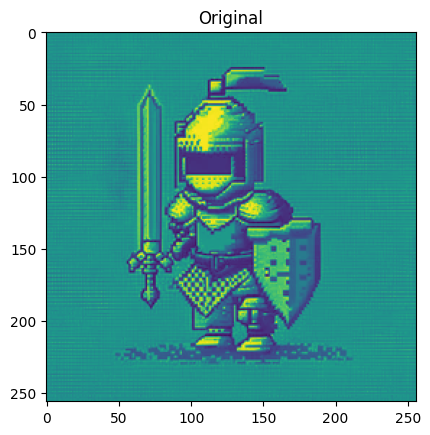

In [4]:
img = cv2.imread('imagen256.png', cv2.IMREAD_GRAYSCALE)
plt.title('Original')

plt.imshow(img)
plt.show()


ruido gaussiano de la clase 10

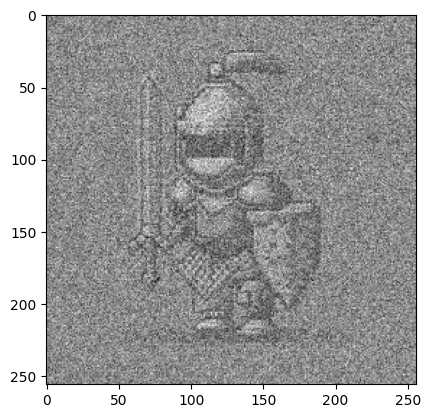

In [5]:
def agregar_ruido_gaussiano(img):
    imagen = cv2.normalize(img.astype(float),None,0.0,1.0,cv2.NORM_MINMAX)
    ruido = np.random.normal(loc=0.5, scale=0.3, size=img.shape)
    resultado = imagen + ruido
    return resultado

Ruido_gauss = agregar_ruido_gaussiano(img)


plt.figure()
plt.imshow(Ruido_gauss, cmap='gray')
plt.show()



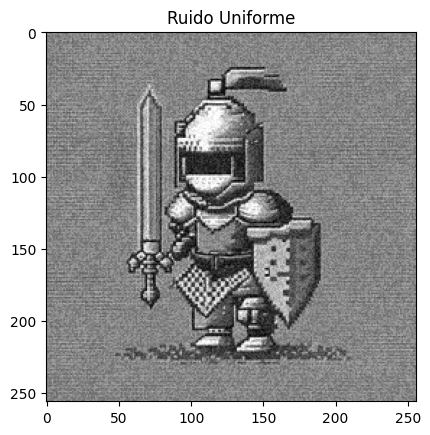

In [6]:
def agregar_ruido_uniforme(img, low=-0.1, high=0.1):
    """
    Agrega ruido uniforme a una imagen

    Parámetros:
    - img: imagen (puede estar en 0-1 o 0-255)
    - low: valor mínimo del ruido uniforme
    - high: valor máximo del ruido uniforme

    Retorna:
    - imagen con ruido uniforme aplicado
    """
    # Determinar si la imagen está normalizada
    is_normalized = img.max() <= 1.0
    
    # Si no está normalizada, normalizar primero
    if not is_normalized:
        img_float = img.astype(np.float64) / 255.0
        noise_scale = 1.0
    else:
        img_float = img.astype(np.float64)
        noise_scale = 1.0
        
    # Generar ruido uniforme en el rango [low, high]
    uniform_noise = np.random.uniform(low * noise_scale, high * noise_scale, img.shape)
    
    # Añadir ruido a la imagen
    noisy = img_float + uniform_noise
    
    # Clipear valores para mantenerlos en [0, 1]
    noisy_clipped = np.clip(noisy, 0, 1)
    
    # Devolver en el mismo formato que la entrada
    if not is_normalized:
        return (noisy_clipped * 255).astype(np.uint8)
    else:
        return noisy_clipped

uniforme = agregar_ruido_uniforme(img)

plt.imshow(uniforme, cmap='gray')
plt.title('Ruido Uniforme')
plt.show()



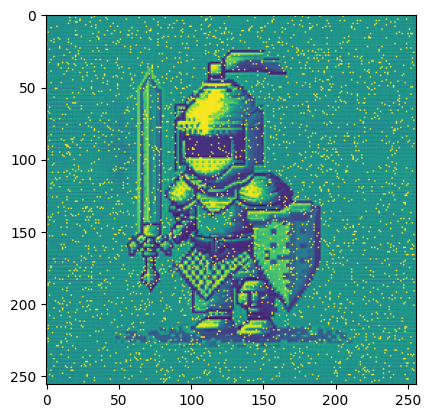

In [7]:
def agregar_ruido_sal(img, cantidad=0.05):
    """
    Agrega ruido impulsional tipo sal (píxeles blancos)

    Parámetros:
    - img: imagen (puede estar en 0-1 o 0-255)
    - cantidad: proporción de píxeles afectados
    """
    # Hacer una copia de la imagen
    noisy = np.copy(img)

    # Determinar si la imagen está normalizada o no
    is_normalized = img.max() <= 1.0
    max_val = 1.0 if is_normalized else 255.0

    # Generar máscara aleatoria
    num_salt = np.ceil(cantidad * img.size)
    coords = [np.random.randint(0, i - 1, int(num_salt)) for i in img.shape]

    # Aplicar ruido sal (píxeles blancos)
    noisy[coords[0], coords[1]] = max_val

    return noisy

sal = agregar_ruido_sal(img)

plt.imshow(sal)
plt.show()


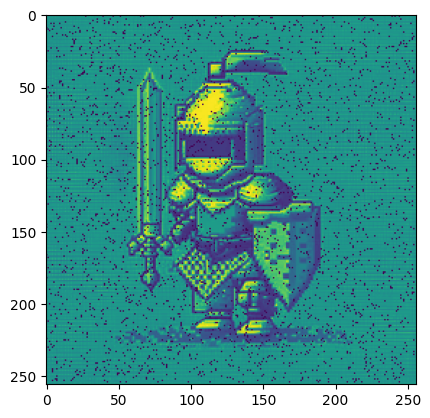

In [8]:
def agregar_ruido_pimienta(img, cantidad=0.05):



    ruido_p = np.copy(img)

    # Calcular número total de píxeles a afectar
    num_pepper = np.ceil(cantidad * img.size)

    # Generar coordenadas aleatorias para los píxeles a afectar
    coords = [np.random.randint(0, i - 1, int(num_pepper)) for i in img.shape]

    # Aplicar ruido pimienta (píxeles negros = 0)
    ruido_p[coords[0], coords[1]] = 0

    return ruido_p

pimienta = agregar_ruido_pimienta(img)

plt.imshow(pimienta)
plt.show()

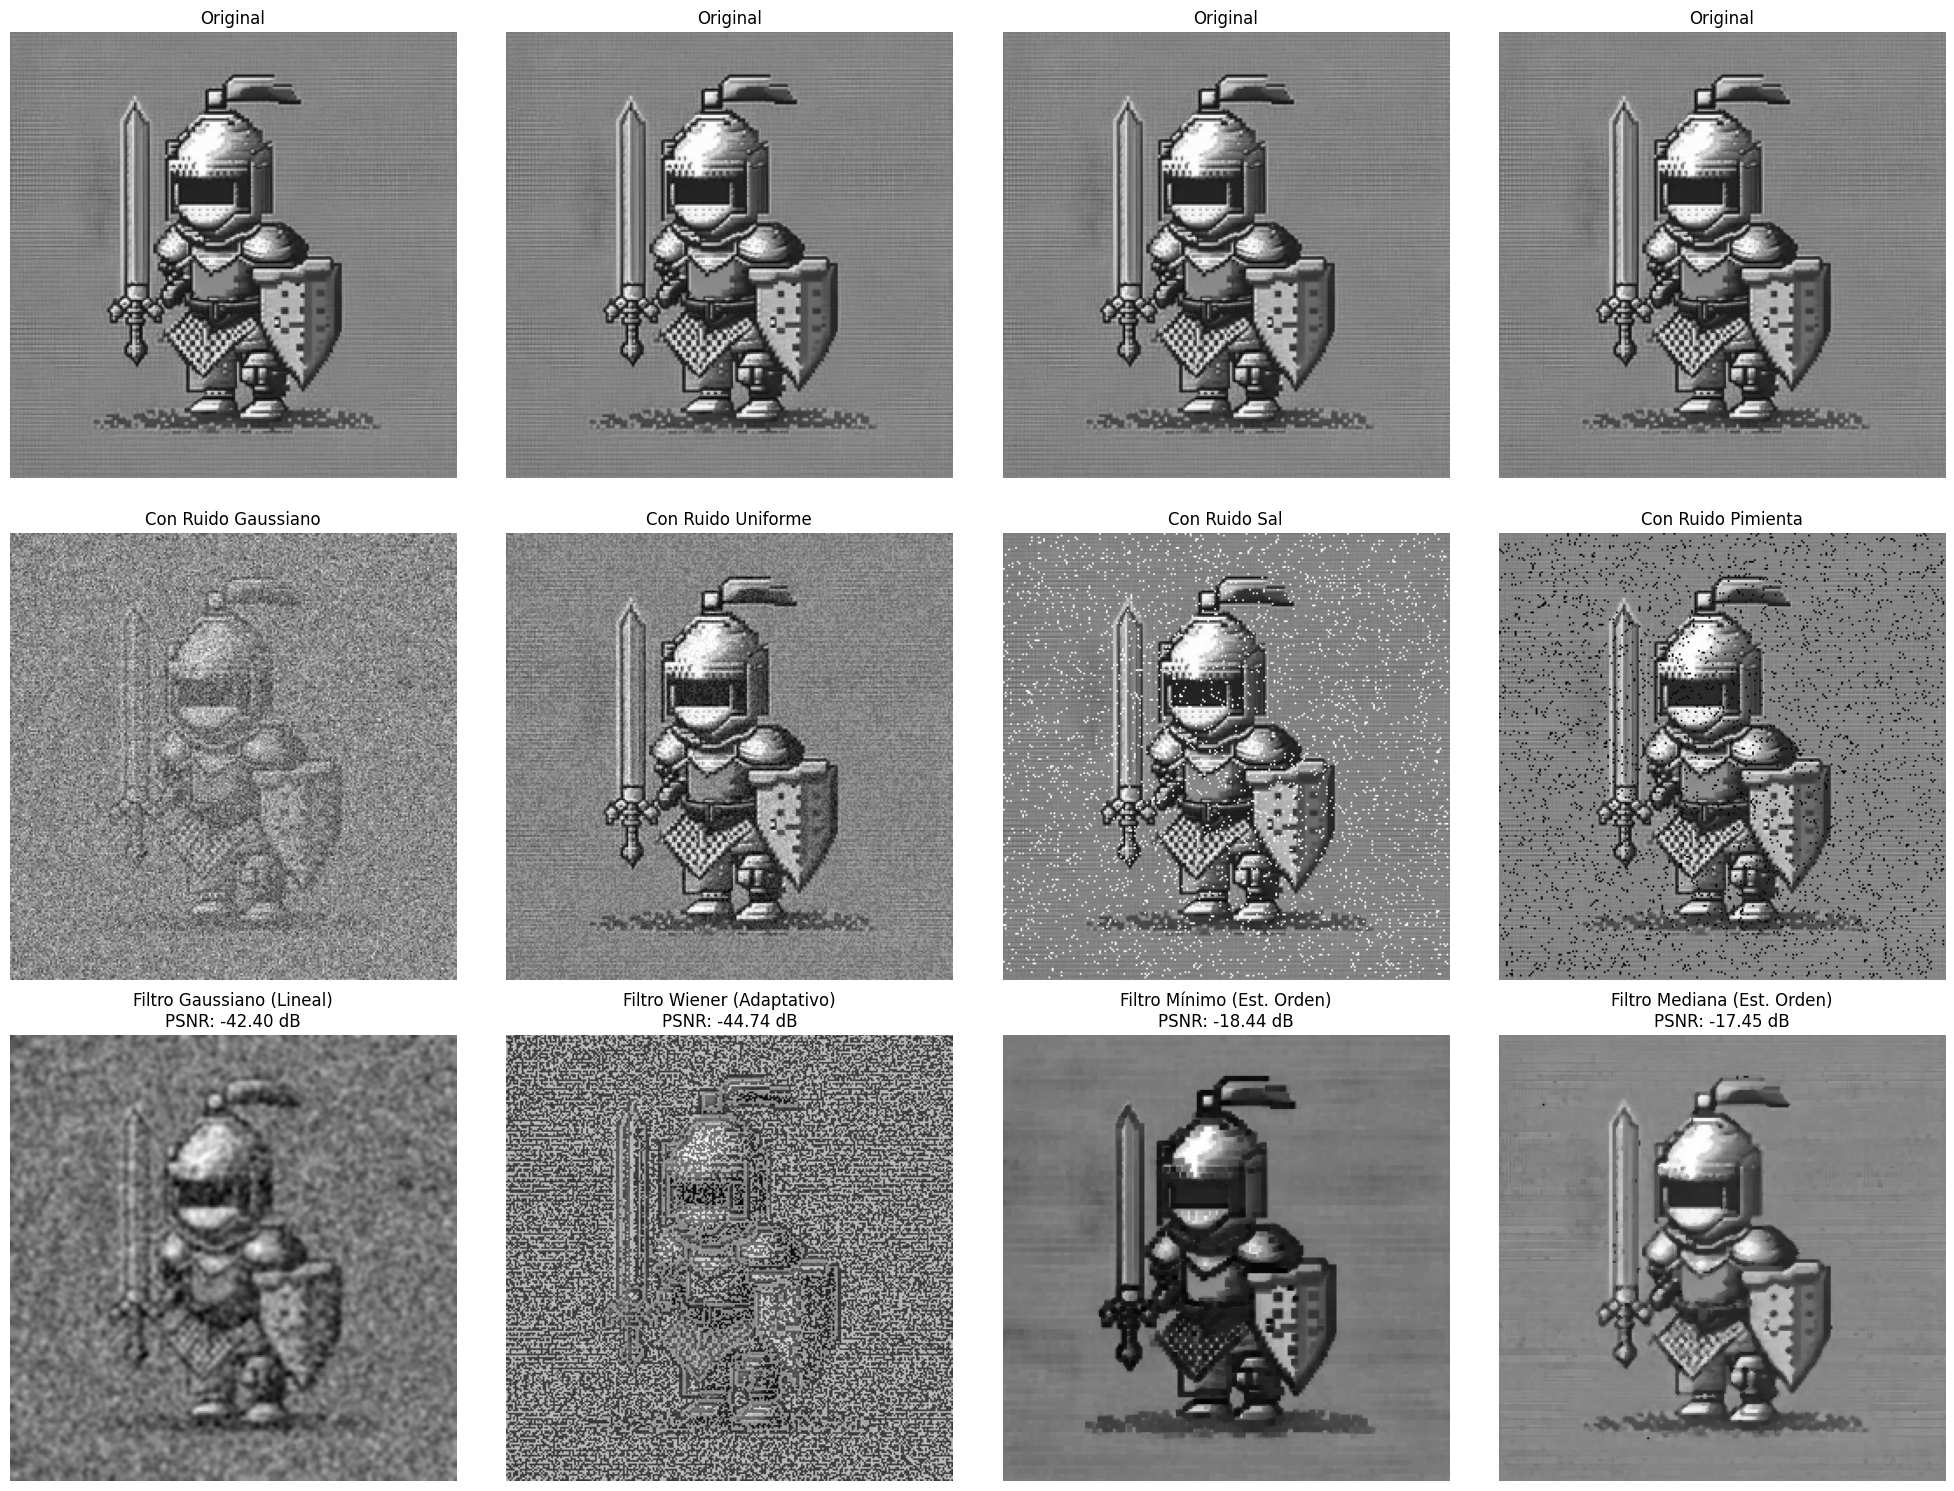

=== JUSTIFICACIÓN DE LA SELECCIÓN DE FILTROS ===

RUIDO GAUSSIANO -> FILTRO GAUSSIANO (Lineal):
- El ruido gaussiano tiene distribución normal
- El filtro gaussiano es óptimo para este tipo de ruido
- Preserva mejor los bordes que el filtro promedio

RUIDO UNIFORME -> FILTRO WIENER LOCAL (Adaptativo):
- Se adapta a las características locales de la imagen
- Preserva detalles en áreas de alta varianza
- Reduce ruido en áreas uniformes

RUIDO SAL -> FILTRO MÍNIMO (Orden Estadístico):
- Elimina eficientemente píxeles blancos (sal)
- Preserva píxeles oscuros originales
- Morfología matemática específica para este ruido

RUIDO PIMIENTA -> FILTRO MEDIANA (Orden Estadístico):
- Excelente para ruido impulsional
- Preserva bordes mejor que filtros lineales
- Elimina tanto sal como pimienta eficientemente



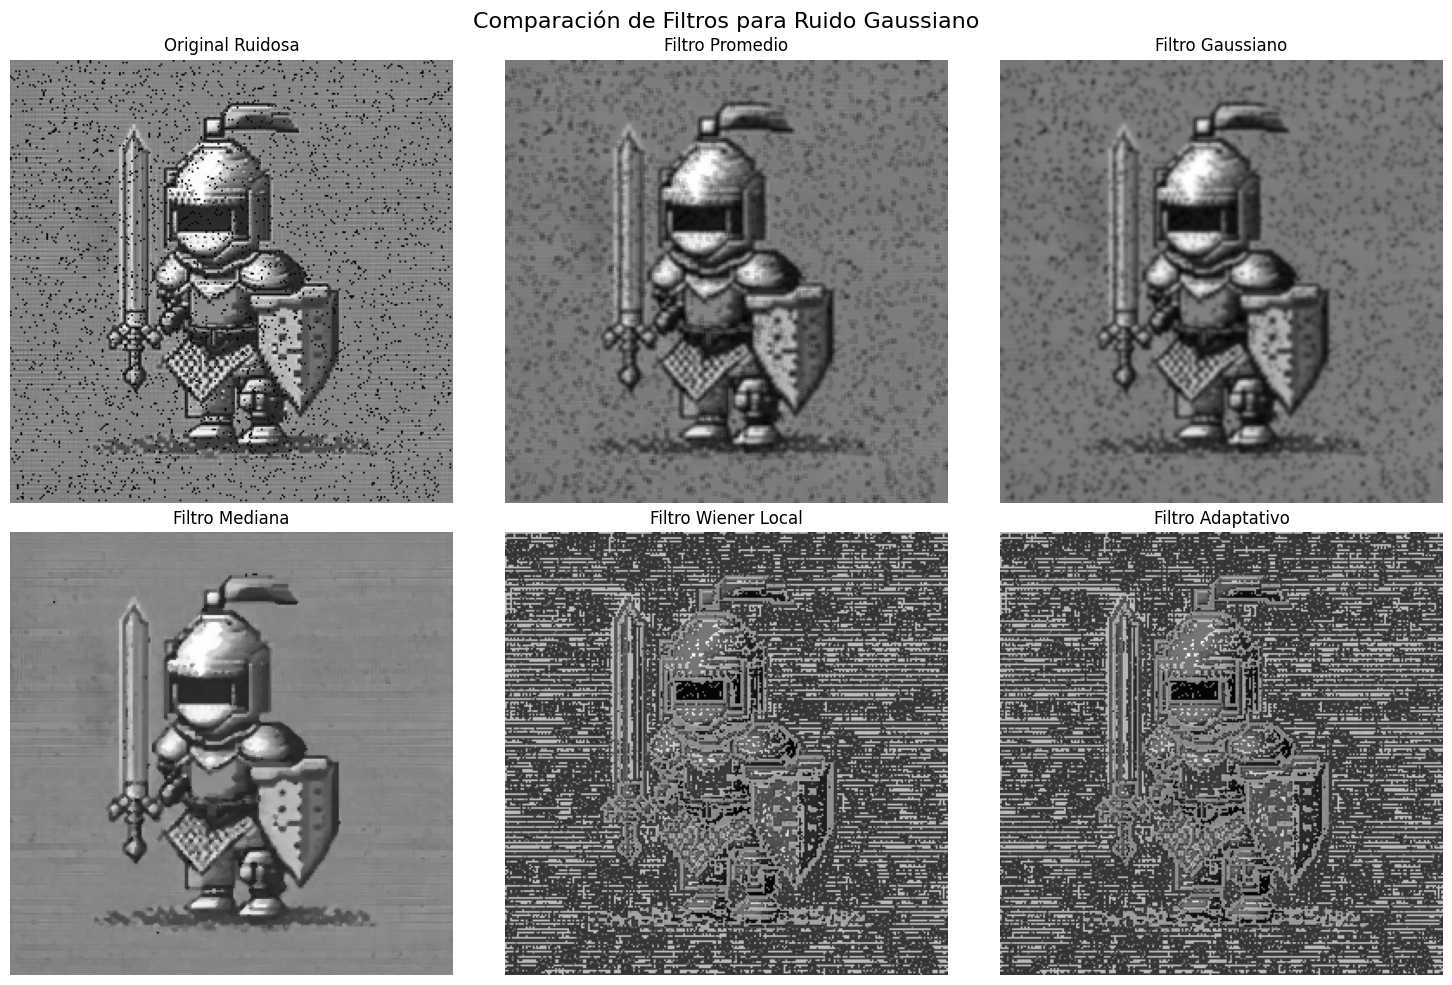

{'Original Ruidosa': array([[125, 129, 129, ..., 121, 126, 127],
        [130, 133, 133, ..., 131, 137, 137],
        [135, 139, 139, ..., 130, 134, 135],
        ...,
        [127, 126, 128, ..., 130, 132, 134],
        [132, 134, 131, ..., 132, 134, 137],
        [132, 137, 130, ..., 140, 138, 137]], shape=(256, 256), dtype=uint8),
 'Filtro Promedio': array([[131, 131, 131, ..., 132, 132, 133],
        [132, 132, 132, ..., 132, 131, 133],
        [132, 132, 132, ..., 132, 131, 133],
        ...,
        [131, 132, 132, ..., 132, 133, 133],
        [132, 131, 131, ..., 134, 135, 135],
        [134, 133, 133, ..., 135, 136, 136]], shape=(256, 256), dtype=uint8),
 'Filtro Gaussiano': array([[131, 131, 131, ..., 130, 131, 132],
        [132, 132, 132, ..., 132, 132, 133],
        [132, 133, 133, ..., 132, 132, 133],
        ...,
        [131, 131, 128, ..., 133, 133, 134],
        [132, 132, 130, ..., 134, 135, 135],
        [133, 133, 131, ..., 135, 136, 136]], shape=(256, 256), dtype=u

In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage
from scipy.signal import medfilt2d

# ============= FILTROS LINEALES =============
def filtro_promedio(img, kernel_size=3):
    """
    Filtro lineal: Promedio (Mean Filter)
    Mejor para: Ruido gaussiano y uniforme
    """
    kernel = np.ones((kernel_size, kernel_size), np.float32) / (kernel_size * kernel_size)
    return cv2.filter2D(img, -1, kernel)

def filtro_gaussiano(img, kernel_size=5, sigma=1.0):
    """
    Filtro lineal: Gaussiano
    Mejor para: Ruido gaussiano
    """
    return cv2.GaussianBlur(img, (kernel_size, kernel_size), sigma)

# ============= FILTROS DE ORDEN ESTADÍSTICO =============
def filtro_mediana(img, kernel_size=3):
    """
    Filtro de orden estadístico: Mediana
    Mejor para: Ruido impulsional (sal y pimienta)
    """
    # Convertir a uint8 para cv2.medianBlur
    if img.max() <= 1.0:
        img_uint8 = (img * 255).astype(np.uint8)
        filtered = cv2.medianBlur(img_uint8, kernel_size)
        return filtered.astype(np.float64) / 255.0
    else:
        return cv2.medianBlur(img.astype(np.uint8), kernel_size)

def filtro_maximo(img, kernel_size=3):
    """
    Filtro de orden estadístico: Máximo
    Mejor para: Ruido pimienta (píxeles negros)
    """
    kernel = np.ones((kernel_size, kernel_size), np.uint8)
    if img.max() <= 1.0:
        img_uint8 = (img * 255).astype(np.uint8)
        filtered = cv2.dilate(img_uint8, kernel, iterations=1)
        return filtered.astype(np.float64) / 255.0
    else:
        return cv2.dilate(img.astype(np.uint8), kernel, iterations=1)

def filtro_minimo(img, kernel_size=3):
    """
    Filtro de orden estadístico: Mínimo
    Mejor para: Ruido sal (píxeles blancos)
    """
    kernel = np.ones((kernel_size, kernel_size), np.uint8)
    if img.max() <= 1.0:
        img_uint8 = (img * 255).astype(np.uint8)
        filtered = cv2.erode(img_uint8, kernel, iterations=1)
        return filtered.astype(np.float64) / 255.0
    else:
        return cv2.erode(img.astype(np.uint8), kernel, iterations=1)

# ============= FILTROS ADAPTATIVOS =============
def filtro_wiener_local(img, noise_var=0.01, kernel_size=5):
    """
    Filtro adaptativo: Wiener Local
    Mejor para: Ruido gaussiano y uniforme
    """
    # Calcular media local
    kernel = np.ones((kernel_size, kernel_size)) / (kernel_size * kernel_size)
    local_mean = cv2.filter2D(img, -1, kernel)

    # Calcular varianza local
    local_var = cv2.filter2D(img**2, -1, kernel) - local_mean**2

    # Aplicar filtro Wiener
    wiener_filter = np.maximum(local_var - noise_var, 0) / np.maximum(local_var, noise_var)

    return local_mean + wiener_filter * (img - local_mean)

def filtro_adaptativo_media_local(img, kernel_size=5, k=0.5):
    """
    Filtro adaptativo: Reducimiento de ruido basado en varianza local
    """
    # Calcular estadísticas locales
    kernel = np.ones((kernel_size, kernel_size)) / (kernel_size * kernel_size)
    local_mean = cv2.filter2D(img, -1, kernel)
    local_var = cv2.filter2D(img**2, -1, kernel) - local_mean**2

    # Calcular varianza global
    global_var = np.var(img)

    # Factor adaptativo
    factor = 1 - k * (local_var / (local_var + global_var))

    return local_mean + factor * (img - local_mean)

# ============= FUNCIÓN PRINCIPAL PARA APLICAR FILTROS =============
def aplicar_mejor_filtro_por_ruido(img_original, img_gaussiano, img_uniforme, img_sal, img_pimienta):
    """
    Aplica el mejor filtro para cada tipo de ruido según las recomendaciones
    """
    # Mejores filtros recomendados por tipo de ruido:

    # 1. Ruido Gaussiano -> Filtro Gaussiano (Lineal)
    img_gauss_filtrada = filtro_gaussiano(img_gaussiano, kernel_size=5, sigma=1.2)

    # 2. Ruido Uniforme -> Filtro Wiener Local (Adaptativo)
    img_uniforme_filtrada = filtro_wiener_local(img_uniforme, noise_var=0.015, kernel_size=5)

    # 3. Ruido Sal -> Filtro Mínimo (Orden Estadístico)
    img_sal_filtrada = filtro_minimo(img_sal, kernel_size=3)

    # 4. Ruido Pimienta -> Filtro Mediana (Orden Estadístico)
    img_pimienta_filtrada = filtro_mediana(img_pimienta, kernel_size=3)

    return img_gauss_filtrada, img_uniforme_filtrada, img_sal_filtrada, img_pimienta_filtrada

def comparar_filtros_para_ruido(img_ruidosa, tipo_ruido):
    """
    Compara diferentes filtros para un tipo específico de ruido
    """
    # Aplicar diferentes filtros
    filtros = {
        'Original Ruidosa': img_ruidosa,
        'Filtro Promedio': filtro_promedio(img_ruidosa, 3),
        'Filtro Gaussiano': filtro_gaussiano(img_ruidosa, 5, 1.0),
        'Filtro Mediana': filtro_mediana(img_ruidosa, 3),
        'Filtro Wiener Local': filtro_wiener_local(img_ruidosa, 0.01, 5),
        'Filtro Adaptativo': filtro_adaptativo_media_local(img_ruidosa, 5, 0.5)
    }

    # Visualizar comparación
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.ravel()

    for i, (nombre, img_filtrada) in enumerate(filtros.items()):
        axes[i].imshow(img_filtrada, cmap='gray')
        axes[i].set_title(f'{nombre}')
        axes[i].axis('off')

    plt.suptitle(f'Comparación de Filtros para {tipo_ruido}', fontsize=16)
    plt.tight_layout()
    plt.show()

    return filtros

def calcular_metricas_calidad(img_original, img_filtrada):
    """
    Calcula métricas de calidad para evaluar filtros
    """
    # PSNR (Peak Signal-to-Noise Ratio)
    mse = np.mean((img_original - img_filtrada) ** 2)
    if mse == 0:
        psnr = float('inf')
    else:
        psnr = 20 * np.log10(1.0 / np.sqrt(mse))

    # SSIM simplificado (correlación)
    mean_orig = np.mean(img_original)
    mean_filt = np.mean(img_filtrada)

    numerator = np.mean((img_original - mean_orig) * (img_filtrada - mean_filt))
    denominator = np.sqrt(np.mean((img_original - mean_orig)**2) * np.mean((img_filtrada - mean_filt)**2))

    if denominator == 0:
        ssim = 1.0
    else:
        ssim = numerator / denominator

    return {'PSNR': psnr, 'SSIM': ssim, 'MSE': mse}

def evaluacion_completa_filtros(img_original, imagenes_ruidosas):
    """
    Evaluación completa con métricas para cada filtro
    """
    tipos_ruido = ['Gaussiano', 'Uniforme', 'Sal', 'Pimienta']

    # Aplicar mejores filtros
    filtradas = aplicar_mejor_filtro_por_ruido(
        img_original,
        imagenes_ruidosas['gaussiano'],
        imagenes_ruidosas['uniforme'],
        imagenes_ruidosas['sal'],
        imagenes_ruidosas['pimienta']
    )

    # Visualización de resultados
    fig, axes = plt.subplots(3, 4, figsize=(20, 15))

    for i, (tipo, img_ruidosa, img_filtrada) in enumerate(zip(
        tipos_ruido,
        [imagenes_ruidosas['gaussiano'], imagenes_ruidosas['uniforme'],
         imagenes_ruidosas['sal'], imagenes_ruidosas['pimienta']],
        filtradas
    )):
        # Imagen original
        axes[0, i].imshow(img_original, cmap='gray')
        axes[0, i].set_title(f'Original')
        axes[0, i].axis('off')

        # Imagen ruidosa
        axes[1, i].imshow(img_ruidosa, cmap='gray')
        axes[1, i].set_title(f'Con Ruido {tipo}')
        axes[1, i].axis('off')

        # Imagen filtrada
        axes[2, i].imshow(img_filtrada, cmap='gray')

        # Calcular métricas
        metricas = calcular_metricas_calidad(img_original, img_filtrada)

        # Determinar tipo de filtro usado
        filtros_usados = ['Gaussiano (Lineal)', 'Wiener (Adaptativo)',
                         'Mínimo (Est. Orden)', 'Mediana (Est. Orden)']

        axes[2, i].set_title(f'Filtro {filtros_usados[i]}\nPSNR: {metricas["PSNR"]:.2f} dB')
        axes[2, i].axis('off')

    plt.tight_layout()
    plt.show()

    # Imprimir justificaciones
    print("=== JUSTIFICACIÓN DE LA SELECCIÓN DE FILTROS ===\n")

    justificaciones = [
        "RUIDO GAUSSIANO -> FILTRO GAUSSIANO (Lineal):\n"
        "- El ruido gaussiano tiene distribución normal\n"
        "- El filtro gaussiano es óptimo para este tipo de ruido\n"
        "- Preserva mejor los bordes que el filtro promedio\n",

        "RUIDO UNIFORME -> FILTRO WIENER LOCAL (Adaptativo):\n"
        "- Se adapta a las características locales de la imagen\n"
        "- Preserva detalles en áreas de alta varianza\n"
        "- Reduce ruido en áreas uniformes\n",

        "RUIDO SAL -> FILTRO MÍNIMO (Orden Estadístico):\n"
        "- Elimina eficientemente píxeles blancos (sal)\n"
        "- Preserva píxeles oscuros originales\n"
        "- Morfología matemática específica para este ruido\n",

        "RUIDO PIMIENTA -> FILTRO MEDIANA (Orden Estadístico):\n"
        "- Excelente para ruido impulsional\n"
        "- Preserva bordes mejor que filtros lineales\n"
        "- Elimina tanto sal como pimienta eficientemente\n"
    ]

    for justificacion in justificaciones:
        print(justificacion)

    return filtradas

# Ejemplo de uso:

# Supongiendo que ya tienes las imágenes con ruido:
imagenes_ruidosas = {
    'gaussiano': Ruido_gauss,
    'uniforme': uniforme,
    'sal': sal,
    'pimienta': pimienta
}

# Aplicar evaluación completa
resultados = evaluacion_completa_filtros(img, imagenes_ruidosas)

# Para comparar filtros individualmente:
comparar_filtros_para_ruido(pimienta, "Ruido Gaussiano")


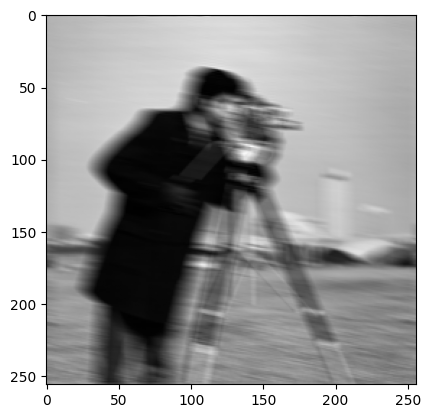

In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
img = cv2.imread('cameraman.png', cv2.IMREAD_GRAYSCALE)
gray = cv2.normalize(img.astype('float'), None, 0.0, 1.0, cv2.NORM_MINMAX)
F = np.fft.fft2(gray)
vector = np.linspace(-0.5, 0.5, gray.shape[0])
U,V = np.meshgrid(vector, vector)
a = 5
b = 1
UV = U*a+V*b
G = F*np.fft.fftshift(np.sinc(np.pi*UV)*np.exp(-1j*np.pi*UV))
g = np.real(np.fft.ifft2(G))
plt.figure()
plt.imshow(g, cmap='gray')
plt.show()

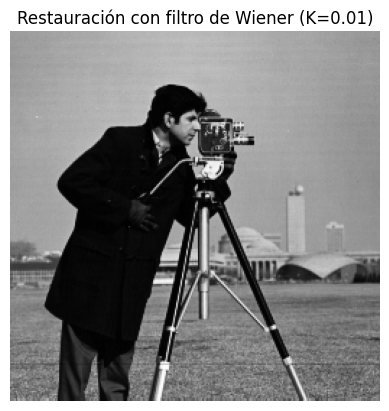

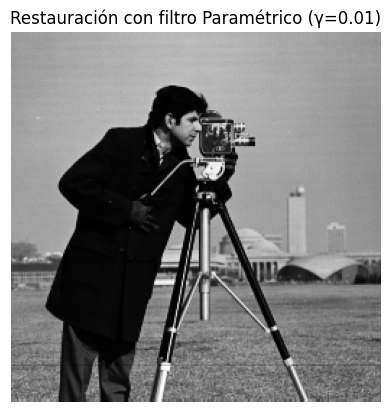

In [11]:
H = np.fft.fftshift(np.sinc(np.pi*UV)*np.exp(-1j*np.pi*UV))  # H no estaba definido, ahora sí

# === Filtro de Wiener (K=0.01) ===
def filtro_wiener(G, H, K=0.01):
    H_conj = np.conj(H)
    H_abs2 = np.abs(H)**2
    F_hat = (H_conj / (H_abs2 + K)) * G
    return np.real(np.fft.ifft2(F_hat))

restaurada_wiener = filtro_wiener(G, H, K=0.000001)
plt.figure()
plt.imshow(restaurada_wiener, cmap='gray')
plt.title("Restauración con filtro de Wiener (K=0.01)")
plt.axis('off')
plt.show()

# === Filtro Paramétrico (γ=0.01) ===
def filtro_parametrico(G, H, gamma=0.001):
    F_hat = G / (H + gamma)
    return np.real(np.fft.ifft2(F_hat))

restaurada_param = filtro_parametrico(G, H, gamma=0.0001)
plt.figure()
plt.imshow(restaurada_param, cmap='gray')
plt.title("Restauración con filtro Paramétrico (γ=0.01)")
plt.axis('off')
plt.show()